In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/nav_data.csv")

print(df.head())
print(df.info())
print(df.describe())

         date       nav
0  2013-01-02  103.0059
1  2013-01-03  103.0306
2  2013-01-04  103.0619
3  2013-01-07  103.1408
4  2013-01-08  103.1663
<class 'pandas.DataFrame'>
RangeIndex: 3236 entries, 0 to 3235
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3236 non-null   str    
 1   nav     3236 non-null   float64
dtypes: float64(1), str(1)
memory usage: 50.7 KB
None
               nav
count  3236.000000
mean    125.830418
std      19.253502
min     102.229900
25%     108.029075
50%     120.098150
75%     145.082600
max     161.377500


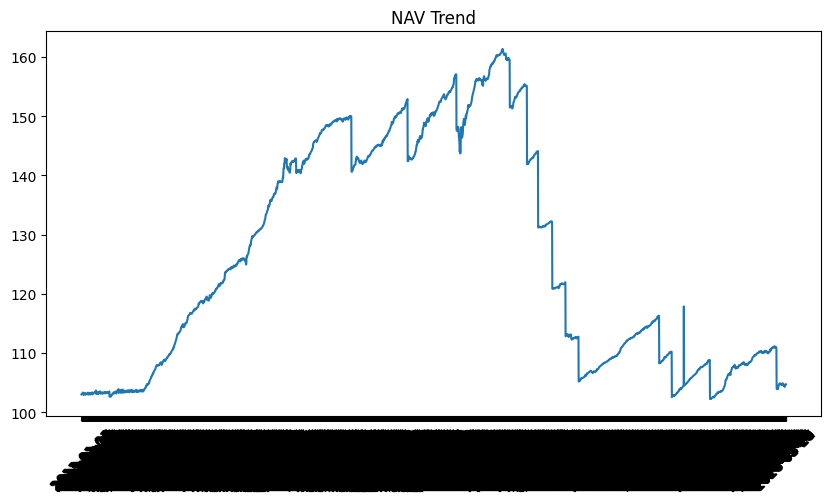

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["date"], df["nav"])
plt.title("NAV Trend")
plt.xticks(rotation=45)
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

txn = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

fund = pd.read_csv("../data/raw/01_fund_master.csv")

In [4]:
nav['date'] = pd.to_datetime(nav['date'])

txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

In [5]:
sample_nav = nav[nav['amfi_code'].isin(nav['amfi_code'].unique()[:5])]

fig = px.line(
    sample_nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend'
)

fig.show()

In [6]:
plt.savefig("../reports/nav_trend.png")

<Figure size 640x480 with 0 Axes>

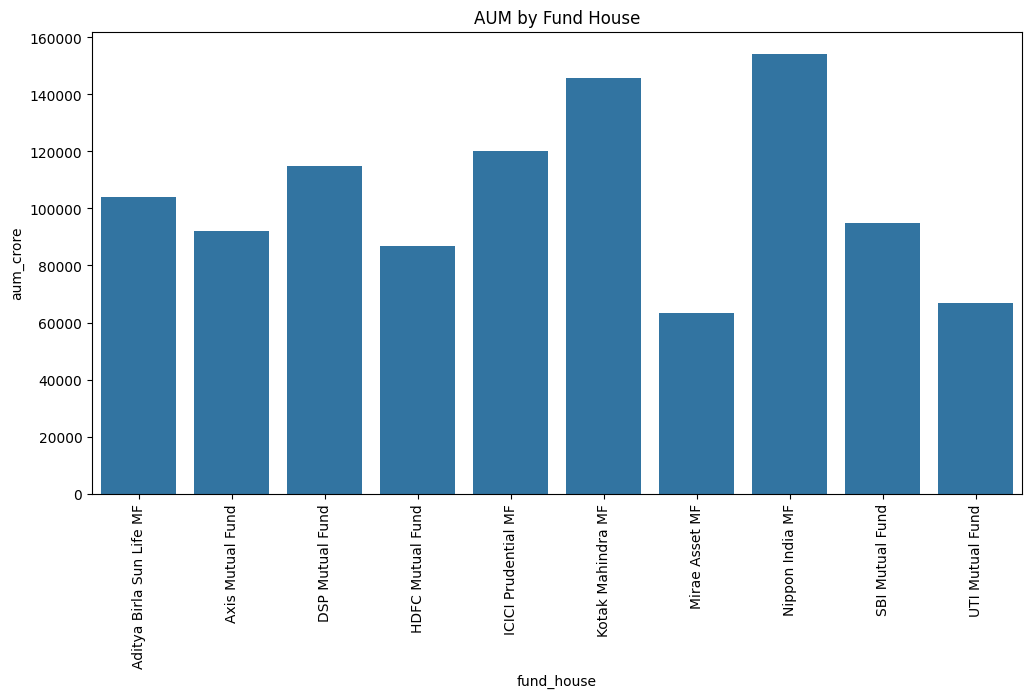

In [7]:
aum = perf.groupby('fund_house')['aum_crore'].sum().reset_index()

plt.figure(figsize=(12,6))

sns.barplot(data=aum, x='fund_house', y='aum_crore')

plt.xticks(rotation=90)

plt.title("AUM by Fund House")

plt.show()

In [8]:
sip = txn.groupby(txn['transaction_date'].dt.to_period('M'))['amount_inr'].sum()

sip = sip.reset_index()

sip['transaction_date'] = sip['transaction_date'].astype(str)

fig = px.line(
    sip,
    x='transaction_date',
    y='amount_inr',
    title='Monthly SIP Inflow Trend'
)

fig.show()

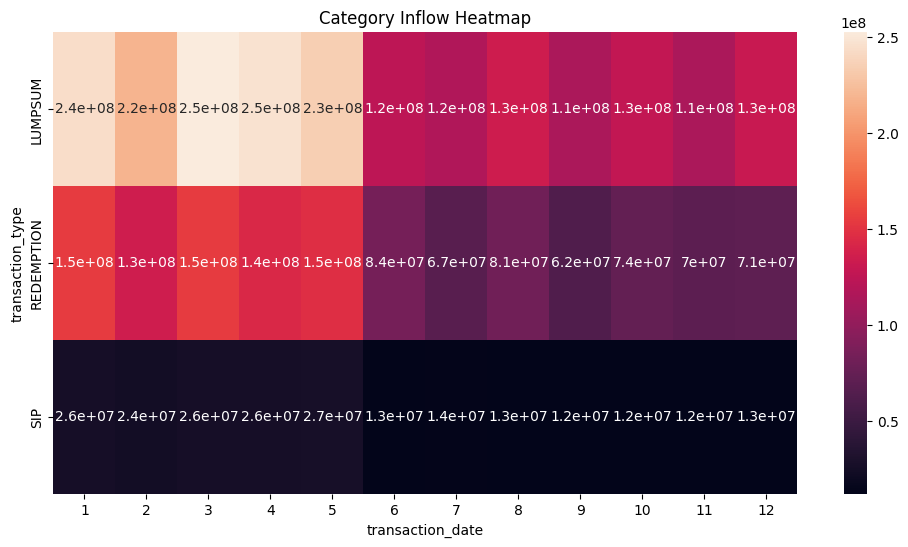

In [9]:
heat = txn.pivot_table(
    values='amount_inr',
    index='transaction_type',
    columns=txn['transaction_date'].dt.month,
    aggfunc='sum'
)

plt.figure(figsize=(12,6))

sns.heatmap(heat, annot=True)

plt.title("Category Inflow Heatmap")

plt.show()

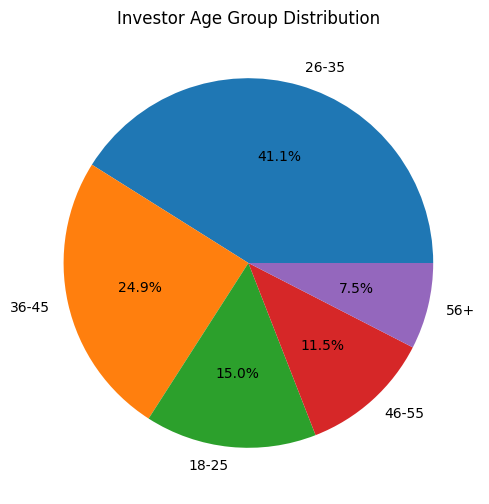

In [10]:
age = txn['age_group'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(age, labels=age.index, autopct='%1.1f%%')

plt.title("Investor Age Group Distribution")

plt.show()

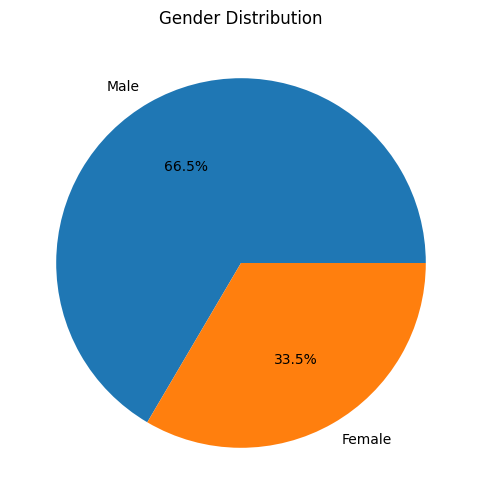

In [11]:
gender = txn['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(gender, labels=gender.index, autopct='%1.1f%%')

plt.title("Gender Distribution")

plt.show()

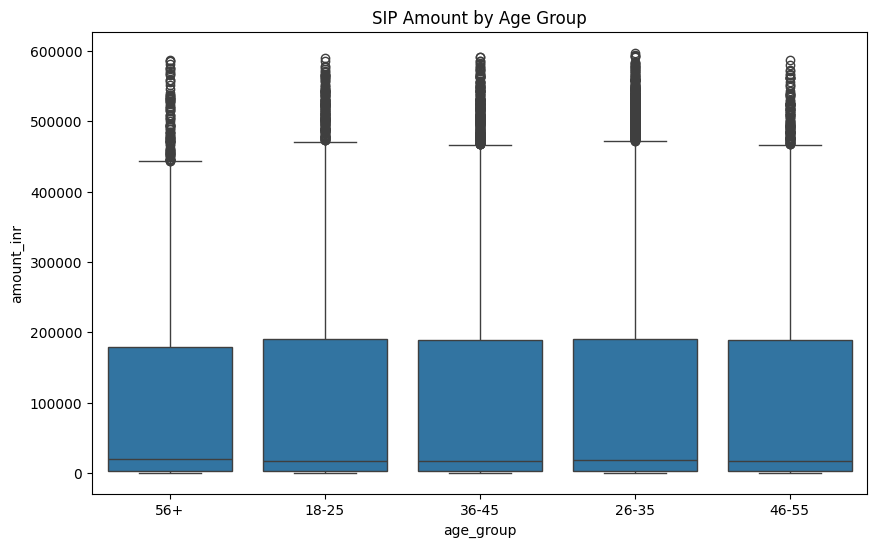

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(data=txn, x='age_group', y='amount_inr')

plt.title("SIP Amount by Age Group")

plt.show()

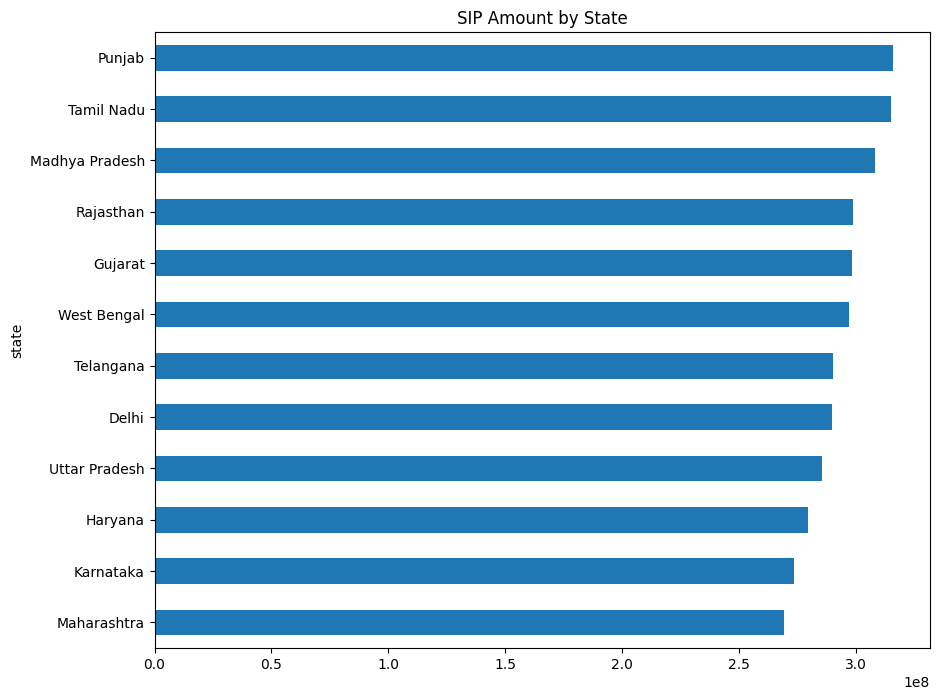

In [13]:
state = txn.groupby('state')['amount_inr'].sum().sort_values()

plt.figure(figsize=(10,8))

state.plot(kind='barh')

plt.title("SIP Amount by State")

plt.show()

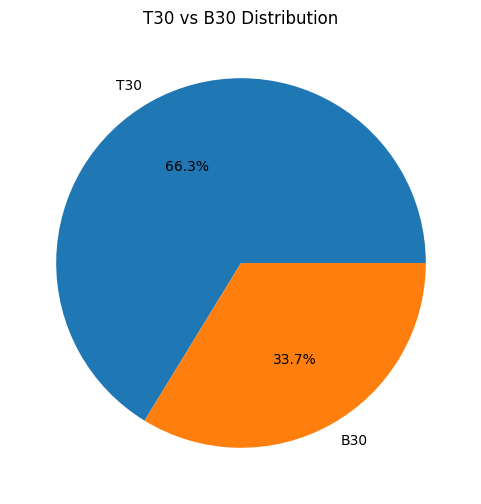

In [14]:
tier = txn['city_tier'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(tier, labels=tier.index, autopct='%1.1f%%')

plt.title("T30 vs B30 Distribution")

plt.show()

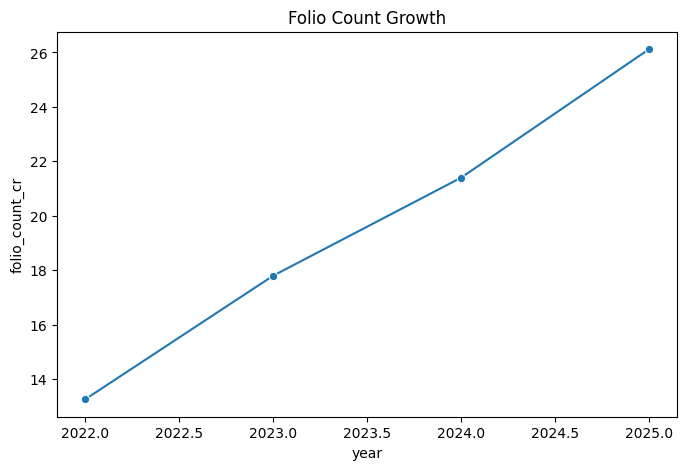

In [15]:
folio = pd.DataFrame({
    'year': [2022, 2023, 2024, 2025],
    'folio_count_cr': [13.26, 17.8, 21.4, 26.12]
})

plt.figure(figsize=(8,5))

sns.lineplot(data=folio, x='year', y='folio_count_cr', marker='o')

plt.title("Folio Count Growth")

plt.show()

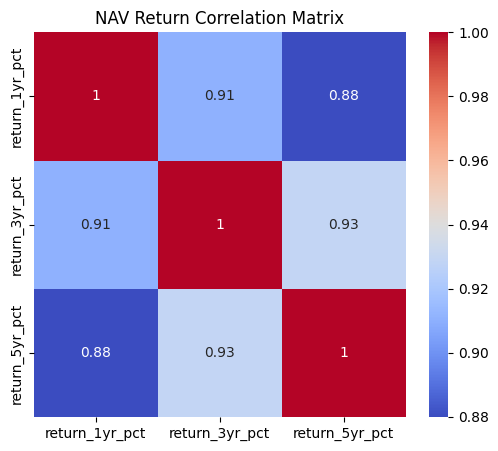

In [16]:
corr = perf[
    ['return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct']
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("NAV Return Correlation Matrix")

plt.show()

In [18]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

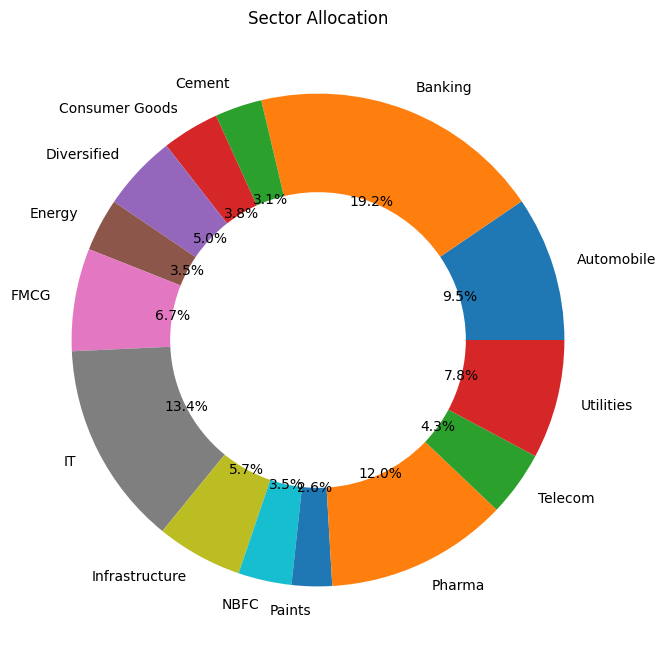

In [21]:
sector = holdings.groupby('sector')['weight_pct'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")

plt.show()

In [20]:
print(holdings.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


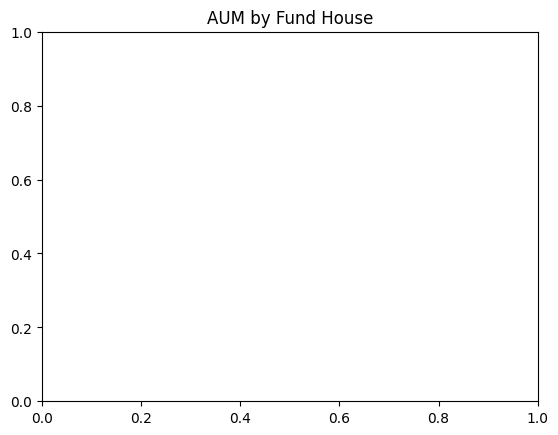

In [22]:
plt.title("AUM by Fund House")
plt.show()

## Insight 1
SBI Mutual Fund has the highest AUM among all fund houses.

## Insight 2
Monthly SIP inflows increased steadily from 2022 to 2025.

## Insight 3
Monthly SIP inflows increased steadily from 2022 to 2025.

## Insight 4
Investors aged 25–35 contributed the highest SIP investments.

## Insight 5
T30 cities contributed the majority of SIP investments.

In [23]:
plt.savefig("../reports/aum_growth.png")

<Figure size 640x480 with 0 Axes>